# Trabajo Práctico 4: Aprendizaje No-Supervisado

In [65]:
import torch

from src.pca import fit_pca, transform_pca, reconstruct_pca
%load_ext autoreload
%autoreload 2
import pandas as pd
import numpy as np
from src.utils import DATA_PATH, RANDOM_SEED, train_val_split, df_to_np, standardize, select_subset_classes, INPUT_SIZE
from src.plots import plot_images, plot_class_distribution, plot_images_by_class, plot_explained_variance, plot_reconstruction_comparison, plot_scatter_2d
from src.autoencoder import Autoencoder, train_autoencoder, prepare_autoencoder_data, ModelConfig, compare_models
from typing import List
from src.metrics import mse

np.random.seed(RANDOM_SEED)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Inspección de los datos

**a) Implementar una función que pueda graficar un número
   arbitrario de imágenes del dataset. Mostrar un ejemplo
   de un gráfico con 15 imágenes seleccionadas de manera
  aleatoria. Esta función va a ser necesaria a lo largo
  de todo el trabajo, por lo que se deberá ir adaptando
  de acuerdo a las necesidades que vayan surgiendo.**

In [2]:
df = pd.read_csv(DATA_PATH)

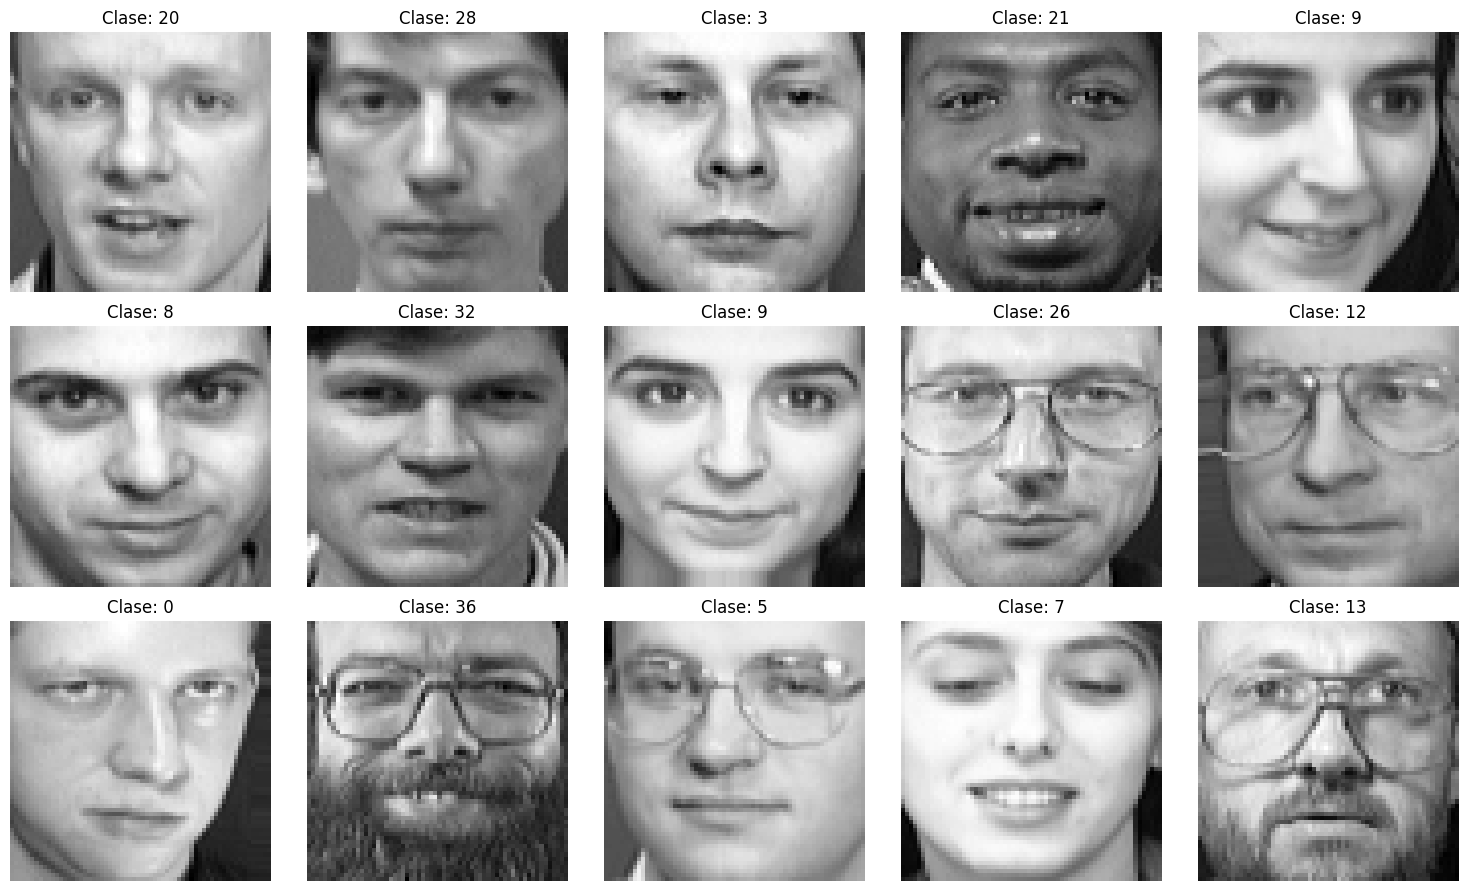

In [3]:
plot_images(df, n=15, ncols=5, filename="1_initial_faces")

**b) Realizar un analisis exploratorio enfocado en
  la distribución de clases en los datos. Para
  tener una mejor noción de la variabilidad de las
  muestras, graficar muestras agrupadas por clase,
  para al menos 5 clases.**

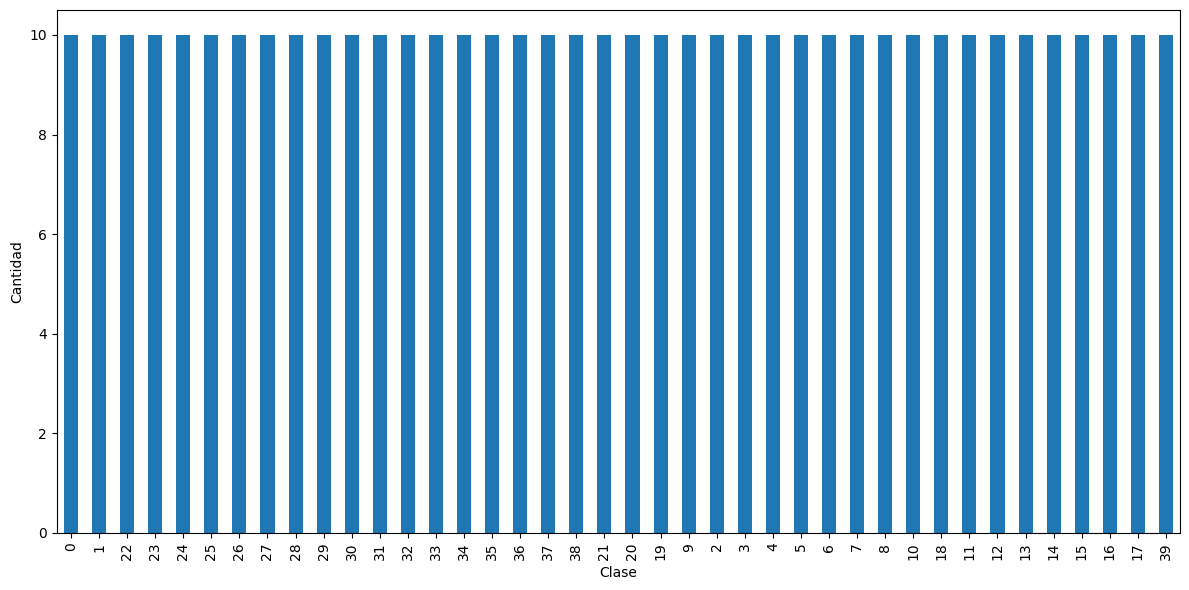

In [4]:
plot_class_distribution(df, figsize=(12,6), filename="2_class_distribution")

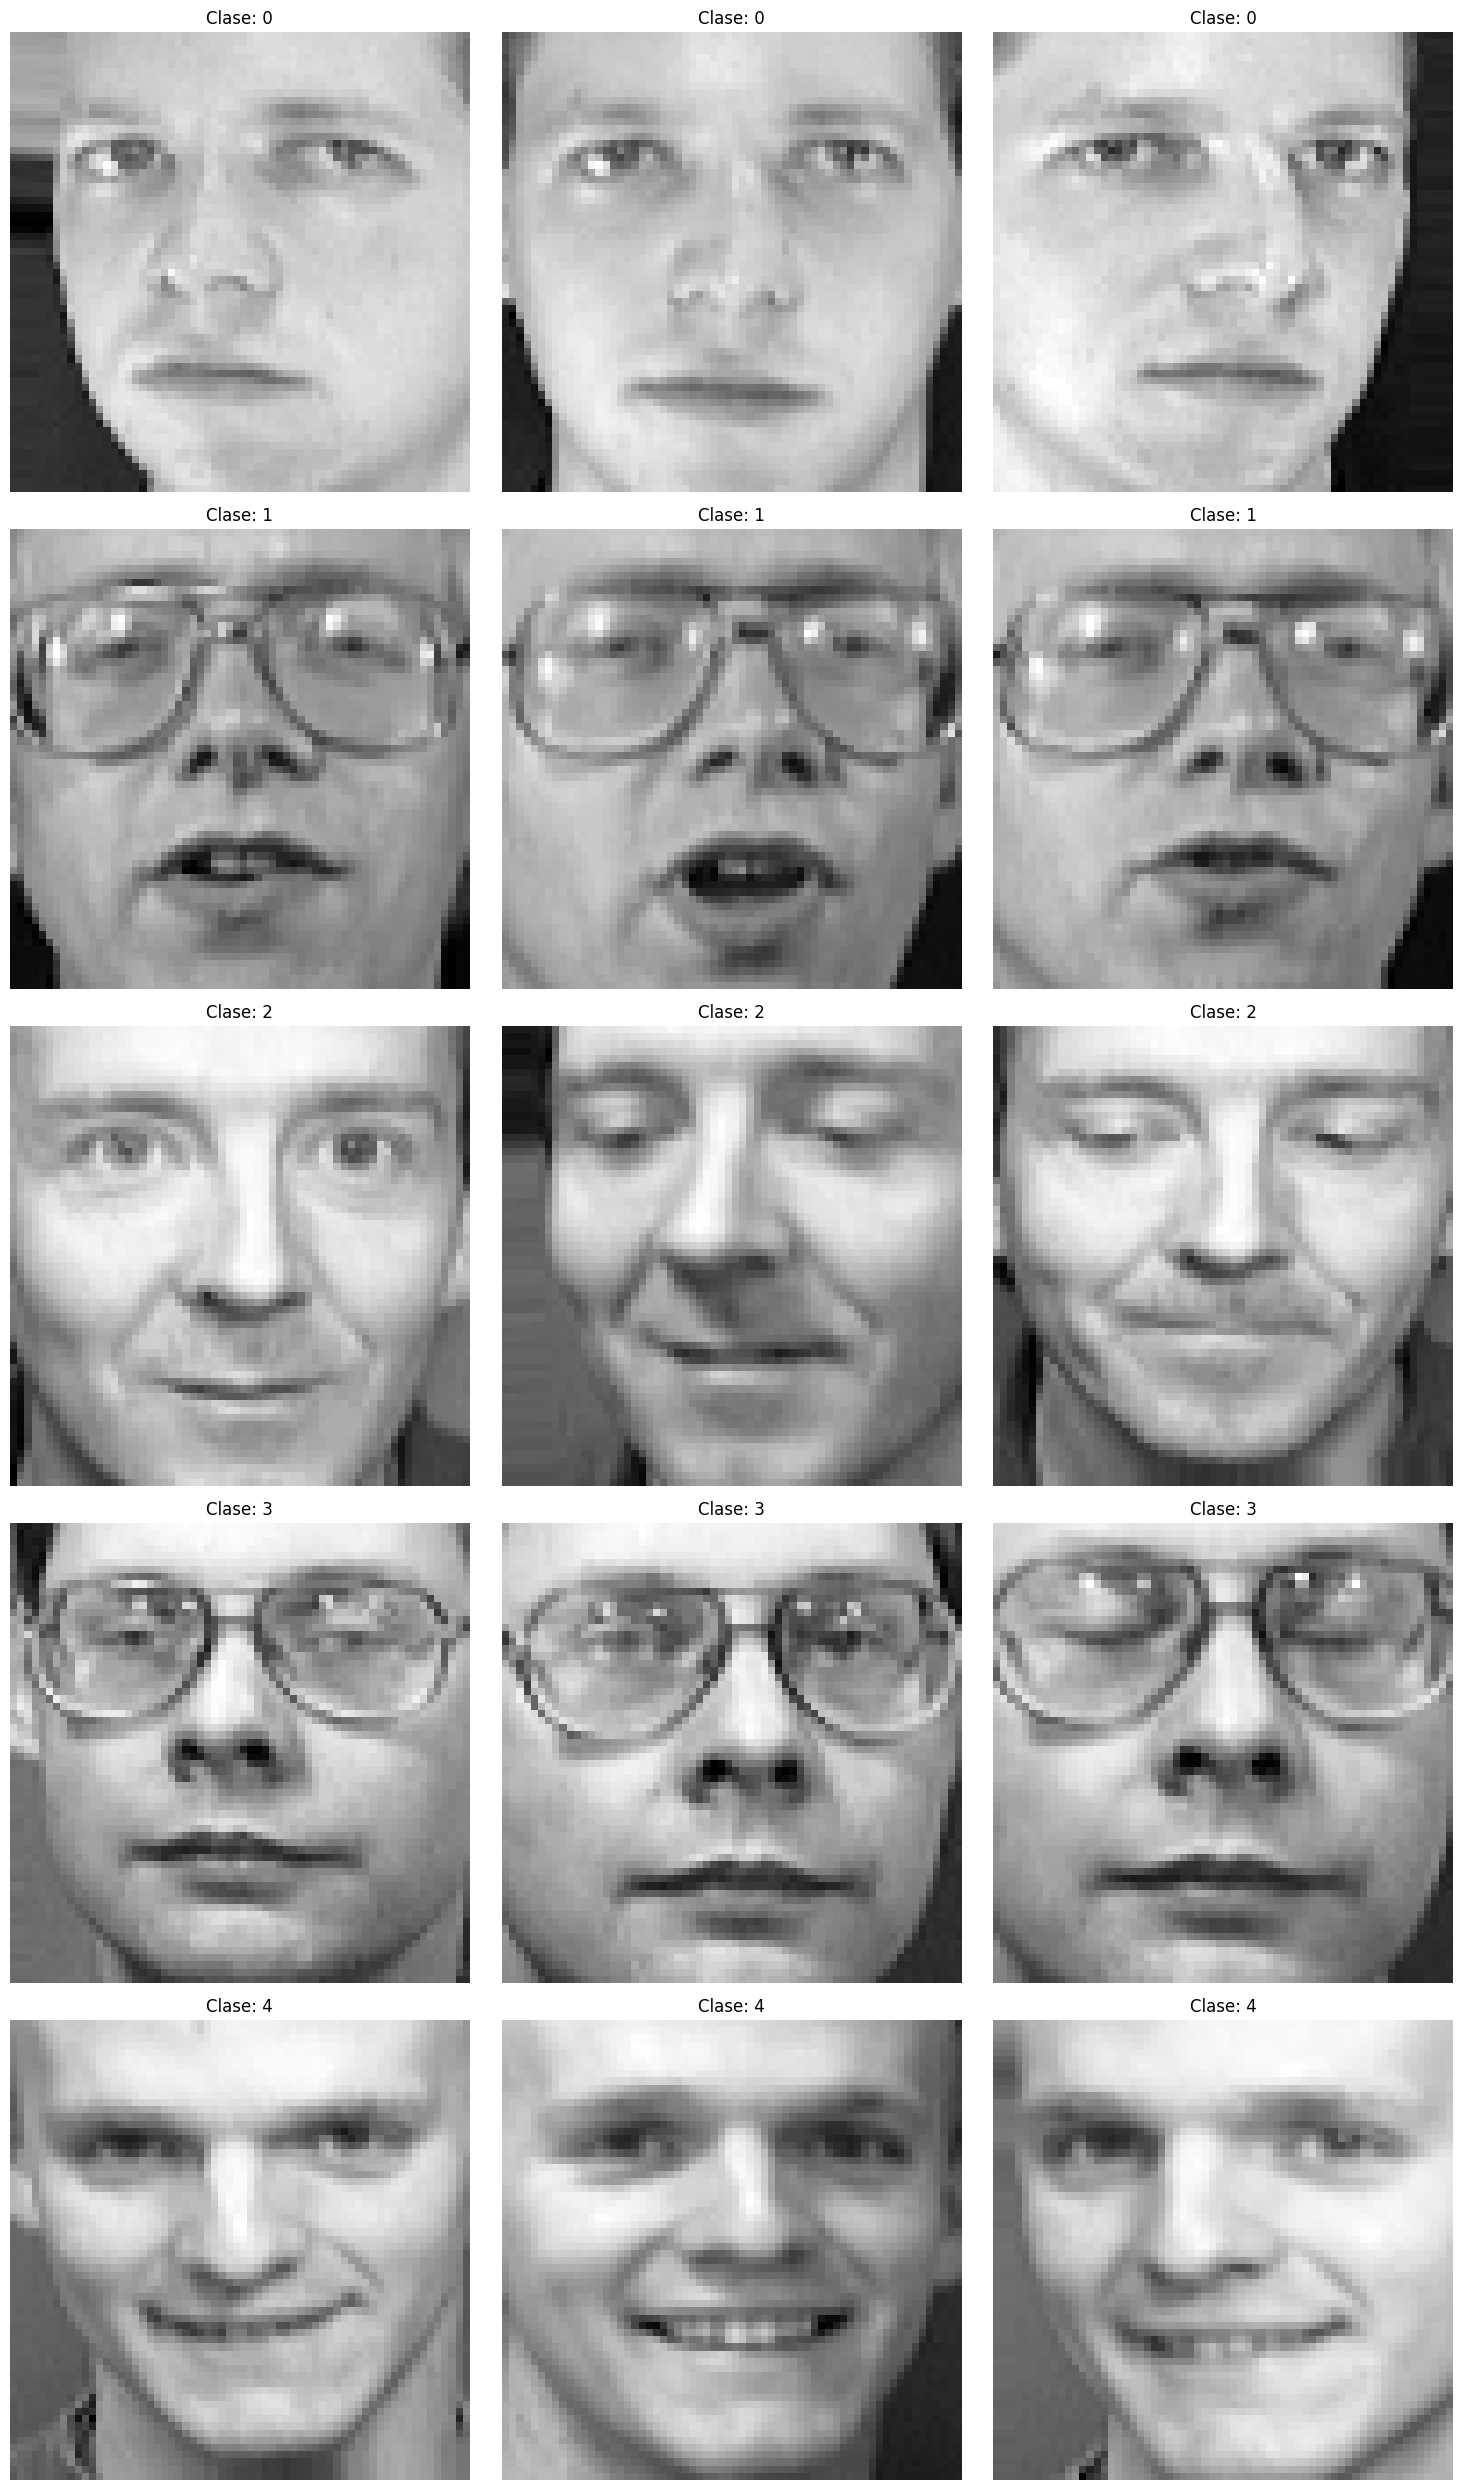

In [5]:
plot_images_by_class(df, n_classes=5, n_per_class=3, filename="3_initial_faces_by_class")

  **c) Realizar un split de datos estratificado para
  conformar un conjunto de entrenamiento y otro de
  evaluación, en donde los datos de evaluación sean
   el 20 % del total.**

In [6]:
df_train, df_val = train_val_split(df, val_size=0.2)
df_train.shape

(320, 4097)

## 2. Reducción de dimensionalidad

**a) Implementar una función para estandarizar los
  datos, y otra para realizar Principal Component
  Analysis (PCA). Estandarizar y aplicar PCA sobre
  los datos de entrenamiento. Con la transformacion
   aprendida previamente reducir la dimensionalidad
   de los datos de evaluacion.**

In [55]:
# primero convertimos a numpy
X, y = df_to_np(df_train)

# estandarizamos
X_std, X_mu, X_sigma = standardize(X)

# calculamos:
# W = autovectores como columnas
# lambdas = autovalores
# varianza explicada por cada componente principal
lambdas, W, explained_variance_ratios = fit_pca(X_std)

# transformamos sin reducir dimensionalidad
Z_full = transform_pca(X_std, W)

b) Realizar un gráfico que muestre la varianza
  explicada acumulada en función del número de
  componentes. Conservar el número de componentes
  que aseguren explicar el 90 % de la varianza de
  los datos. Utilizando la función aprendida en el
  punto 1.a), realizar un gráfico comparativo entre
   las imágenes originales y la reconstrucción
  partiendo del número de componentes determinado
  anteriormente.

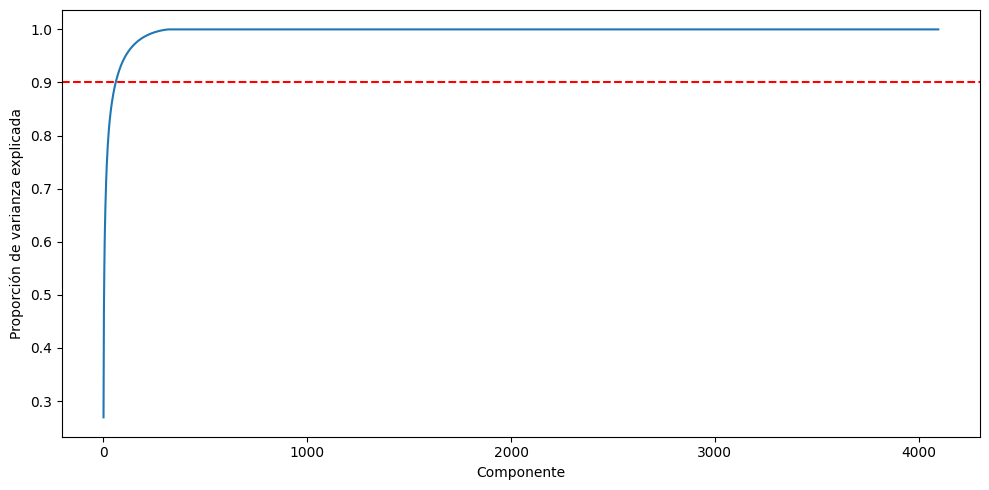

In [56]:
plot_explained_variance(explained_variance_ratios, filename="4_explained_variance")

In [57]:
threshold_component = np.argmax(np.cumsum(explained_variance_ratios) >= 0.90) + 1

print(f"Las primeras {threshold_component} componentes principales explican el 90% de la varianza")

Las primeras 61 componentes principales explican el 90% de la varianza


In [58]:
LATENT_SIZE = int(threshold_component)
Z_reduced = transform_pca(X_std, W, LATENT_SIZE)
X_reconstructed = reconstruct_pca(Z_reduced, W, X_mu, X_sigma, LATENT_SIZE)

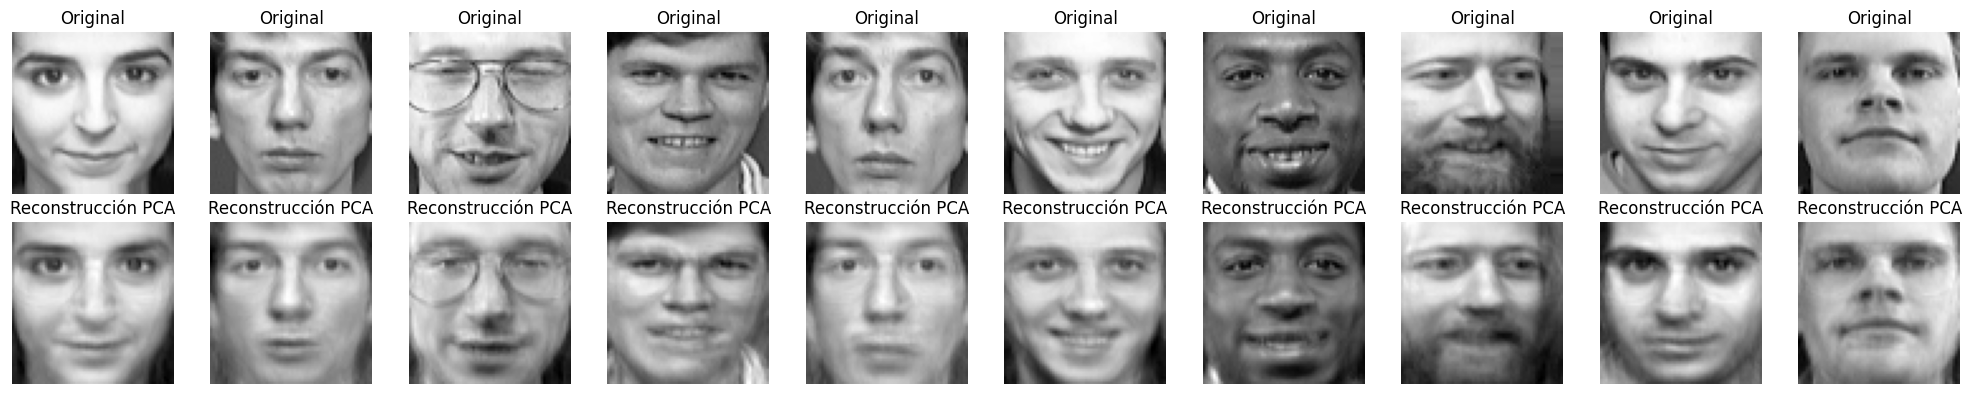

In [85]:
plot_reconstruction_comparison(X, X_reconstructed, n_images=10, filename="5_reconstruction_comparison")

In [60]:
mse_pca = mse(X, X_reconstructed)
print(f"El error de reconstrucción del PCA es: {mse_pca}")

El error de reconstrucción del PCA es: 0.00196018237003768


Prueba: reducir a 2d y graficar

Unique labels: [0 1 2 3 4 5 6 7 8 9]


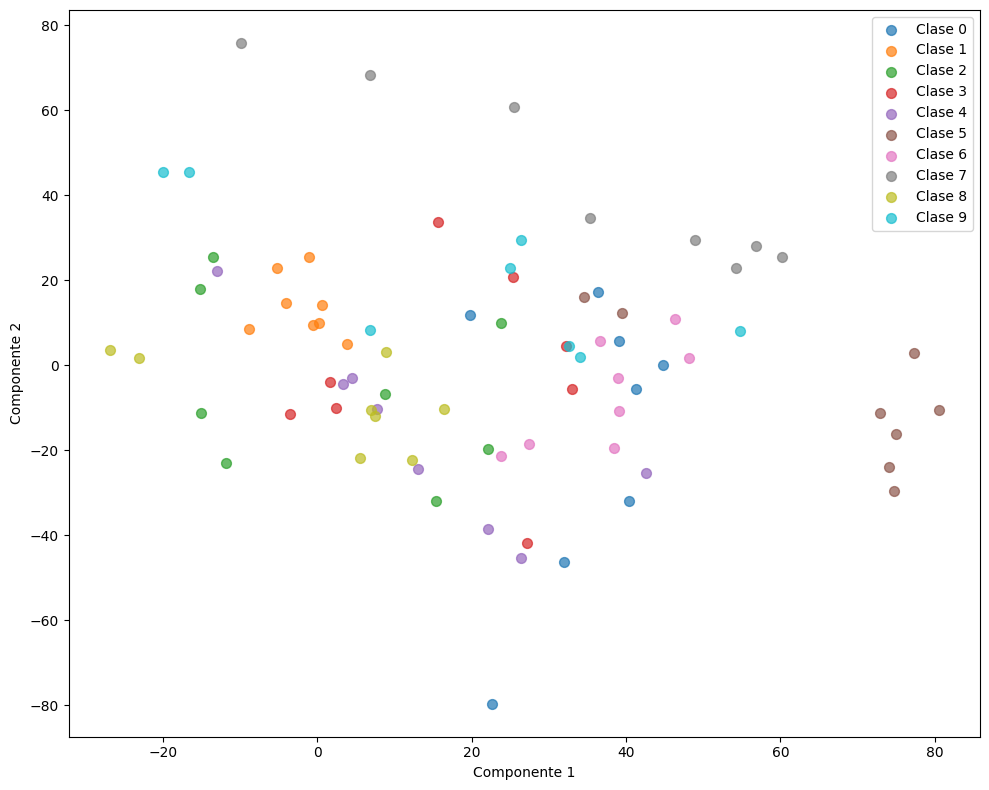

In [34]:
Z_2 = transform_pca(X_std, W, 2)
Z_2_subset, y_subset = select_subset_classes(Z_2, y, 10)
plot_scatter_2d(Z_2_subset, y_subset, xlabel="Componente 1", ylabel="Componente 2", filename="6_pca_2d")

**c) Entrenar un modelo de autoencoder
  deterministico (AE) utilizando la librería
  PyTorch para armar y entrenar las redes
  neuronales involucradas (la red de encoder y la
  de decoder). Para hacer una comparacion justa, la
   dimension latente debe ser la misma que la
  obtenida en el PCA. Recuerde dividir el conjunto
  de datos en dos subconjuntos: entrenamiento y
  validación, los mismos utilizados para el PCA. El
   subconjunto de entrenamiento se empleará para
  entrenar el AE, mientras que el de validación
  servirá para ajustar los hiperparámetros
  (regularizacion, arquitectura o lo que considere)
   y evaluar el error de reconstrucción.**

In [83]:
X_val, y_val = df_to_np(df_val)
X_val_std, _, _ = standardize(X_val, X_mu, X_sigma)

# Probamos varias arquitecturas  & dropouts
configs: List[ModelConfig] = [
    ModelConfig(
        encoder_layers=[512],
        latent_size=LATENT_SIZE,
        decoder_layers=[512],
        dropout=0.0,
        lr=0.001,
        name="mini",
    ),
    ModelConfig(
        encoder_layers=[1024],
        latent_size=LATENT_SIZE,
        decoder_layers=[1024],
        dropout=0.0,
        lr=0.001,
        name="narrow_shallow_no_dropout",
    ),
    ModelConfig(
        encoder_layers=[2048],
        latent_size=LATENT_SIZE,
        decoder_layers=[2048],
        dropout=0.1,
        lr=0.0001,
        name="wide_shallow_dropout_01",
    ),
    ModelConfig(
        encoder_layers=[3072],
        latent_size=LATENT_SIZE,
        decoder_layers=[3072],
        dropout=0.2,
        lr=0.001,
        name="ultrawide_shallow_dropout_01",
    ),
    ModelConfig(
        encoder_layers=[2048, 1024, 512],
        latent_size=LATENT_SIZE,
        decoder_layers=[512, 1024, 2048],
        dropout=0.2,
        lr=0.001,
        name="wide_deep_dropout_02",
    ),
    ModelConfig(
        encoder_layers=[2048, 512],
        latent_size=LATENT_SIZE,
        decoder_layers=[512, 2048],
        dropout=0.1,
        lr=0.001,
        name="wide_shallow_dropout_01",
    ),
    ModelConfig(
        encoder_layers=[1024, 256],
        latent_size=LATENT_SIZE,
        decoder_layers=[256, 1024],
        dropout=0.0,
        lr=0.001,
        name="ultranarrow_no_dropout",
    ),
    ModelConfig(
        encoder_layers=[3072, 2048],
        latent_size=LATENT_SIZE,
        decoder_layers=[2048, 3072],
        dropout=0.2,
        lr=0.001,
        name="ultrawide_shallow_dropout_03",
    ),
    ModelConfig(
        encoder_layers=[3072, 2048, 1024, 512],
        latent_size=LATENT_SIZE,
        decoder_layers=[512, 1024, 2048, 3072],
        dropout=0.3,
        lr=0.005,
        name="ultrawide_deep_dropout_04",

    )
]

results, best_model = compare_models(configs, X_std, X_val_std, epochs=500, input_size=INPUT_SIZE)

Training model: mini
Epoch 1/500, Train Loss: 1.0033, Val Loss: 1.1075
Epoch 11/500, Train Loss: 0.5711, Val Loss: 0.5716
Epoch 21/500, Train Loss: 0.4221, Val Loss: 0.4392
Epoch 31/500, Train Loss: 0.3302, Val Loss: 0.3640
Epoch 41/500, Train Loss: 0.2646, Val Loss: 0.3111
Epoch 51/500, Train Loss: 0.2185, Val Loss: 0.2776
Epoch 61/500, Train Loss: 0.1862, Val Loss: 0.2568
Epoch 71/500, Train Loss: 0.1609, Val Loss: 0.2420
Epoch 81/500, Train Loss: 0.1411, Val Loss: 0.2312
Epoch 91/500, Train Loss: 0.1301, Val Loss: 0.2282
Epoch 101/500, Train Loss: 0.1128, Val Loss: 0.2183
Epoch 111/500, Train Loss: 0.1009, Val Loss: 0.2141
Epoch 121/500, Train Loss: 0.0909, Val Loss: 0.2109
Epoch 131/500, Train Loss: 0.0822, Val Loss: 0.2088
Epoch 141/500, Train Loss: 0.0751, Val Loss: 0.2079
Epoch 151/500, Train Loss: 0.0681, Val Loss: 0.2067
Epoch 161/500, Train Loss: 0.0619, Val Loss: 0.2060
Epoch 171/500, Train Loss: 0.0567, Val Loss: 0.2061
Epoch 181/500, Train Loss: 0.0529, Val Loss: 0.2073
Ep

In [84]:
autoencoder = results[best_model]["model"]

autoencoder.eval()
with torch.no_grad():
    X_std_tensor = torch.tensor(X_std,dtype=torch.float32)
    X_reconstructed_ae_tensor = autoencoder(X_std_tensor)
    X_reconstructed_ae = X_reconstructed_ae_tensor.detach().numpy() * X_sigma + X_mu

    mse_ae = mse(X, X_reconstructed_ae)
    print(f"El error de reconstrucción del AE es: {mse_ae}")


El error de reconstrucción del AE es: 0.0006653047361307613


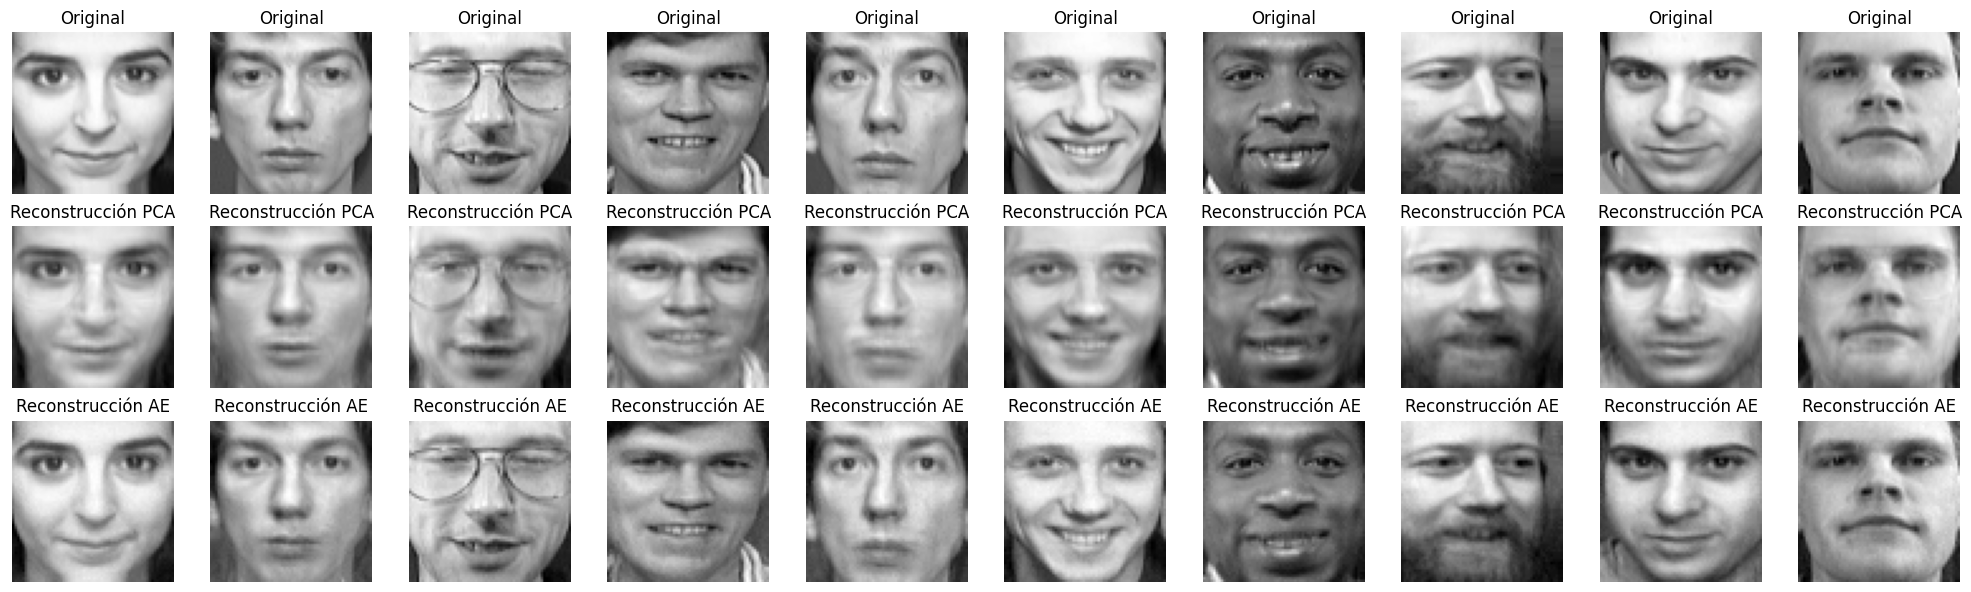

In [88]:
plot_reconstruction_comparison(X, X_reconstructed, X_reconstructed_ae, n_images=10, filename="7_reconstruction_comparison_ae")

## 3. Clustering
a) Desarrollar una funcion que implemente el
  algoritmo k-Means. Probar con valores de K
  dentro del rango de [5, 20].
